In [1]:
# Cell 1: Generate realistic customer data
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

np.random.seed(42)

# Number of customers
n_customers = 10000

# Generate customer data
data = {
    'customer_id': range(1, n_customers + 1),
    'age': np.random.randint(18, 70, n_customers),
    'gender': np.random.choice(['Male', 'Female'], n_customers),
    'tenure_months': np.random.randint(1, 72, n_customers),
    'monthly_charges': np.round(np.random.uniform(20, 120, n_customers), 2),
    'total_charges': np.round(np.random.uniform(100, 8000, n_customers), 2),
    'contract_type': np.random.choice(['Month-to-month', 'One year', 'Two year'], 
                                       n_customers, p=[0.5, 0.3, 0.2]),
    'payment_method': np.random.choice(['Electronic check', 'Mailed check', 
                                        'Bank transfer', 'Credit card'], n_customers),
    'paperless_billing': np.random.choice(['Yes', 'No'], n_customers),
    'monthly_minutes': np.random.randint(0, 1500, n_customers),
    'num_complaints': np.random.poisson(0.5, n_customers),
    'avg_monthly_gb_download': np.round(np.random.exponential(50, n_customers), 1),
    'streaming_tv': np.random.choice(['Yes', 'No'], n_customers),
    'streaming_movies': np.random.choice(['Yes', 'No'], n_customers),
    'device_protection': np.random.choice(['Yes', 'No'], n_customers),
    'tech_support': np.random.choice(['Yes', 'No'], n_customers),
}

df = pd.DataFrame(data)

# Create churn label based on realistic rules
df['churn'] = (
    ((df['tenure_months'] < 12) & (df['monthly_charges'] > 70)) |
    (df['num_complaints'] > 2) |
    ((df['contract_type'] == 'Month-to-month') & (df['monthly_charges'] > 80)) |
    (df['payment_method'] == 'Electronic check') |
    (df['tech_support'] == 'No') |
    (np.random.random(n_customers) < 0.1)  # Random churn
).astype(int)

# Save data
df.to_csv('customer_data.csv', index=False)
print(f"✅ Generated {n_customers} customers")
print(f"📊 Churn rate: {df['churn'].mean():.1%}")
print(f"📋 Features: {list(df.columns)}")

✅ Generated 10000 customers
📊 Churn rate: 74.9%
📋 Features: ['customer_id', 'age', 'gender', 'tenure_months', 'monthly_charges', 'total_charges', 'contract_type', 'payment_method', 'paperless_billing', 'monthly_minutes', 'num_complaints', 'avg_monthly_gb_download', 'streaming_tv', 'streaming_movies', 'device_protection', 'tech_support', 'churn']


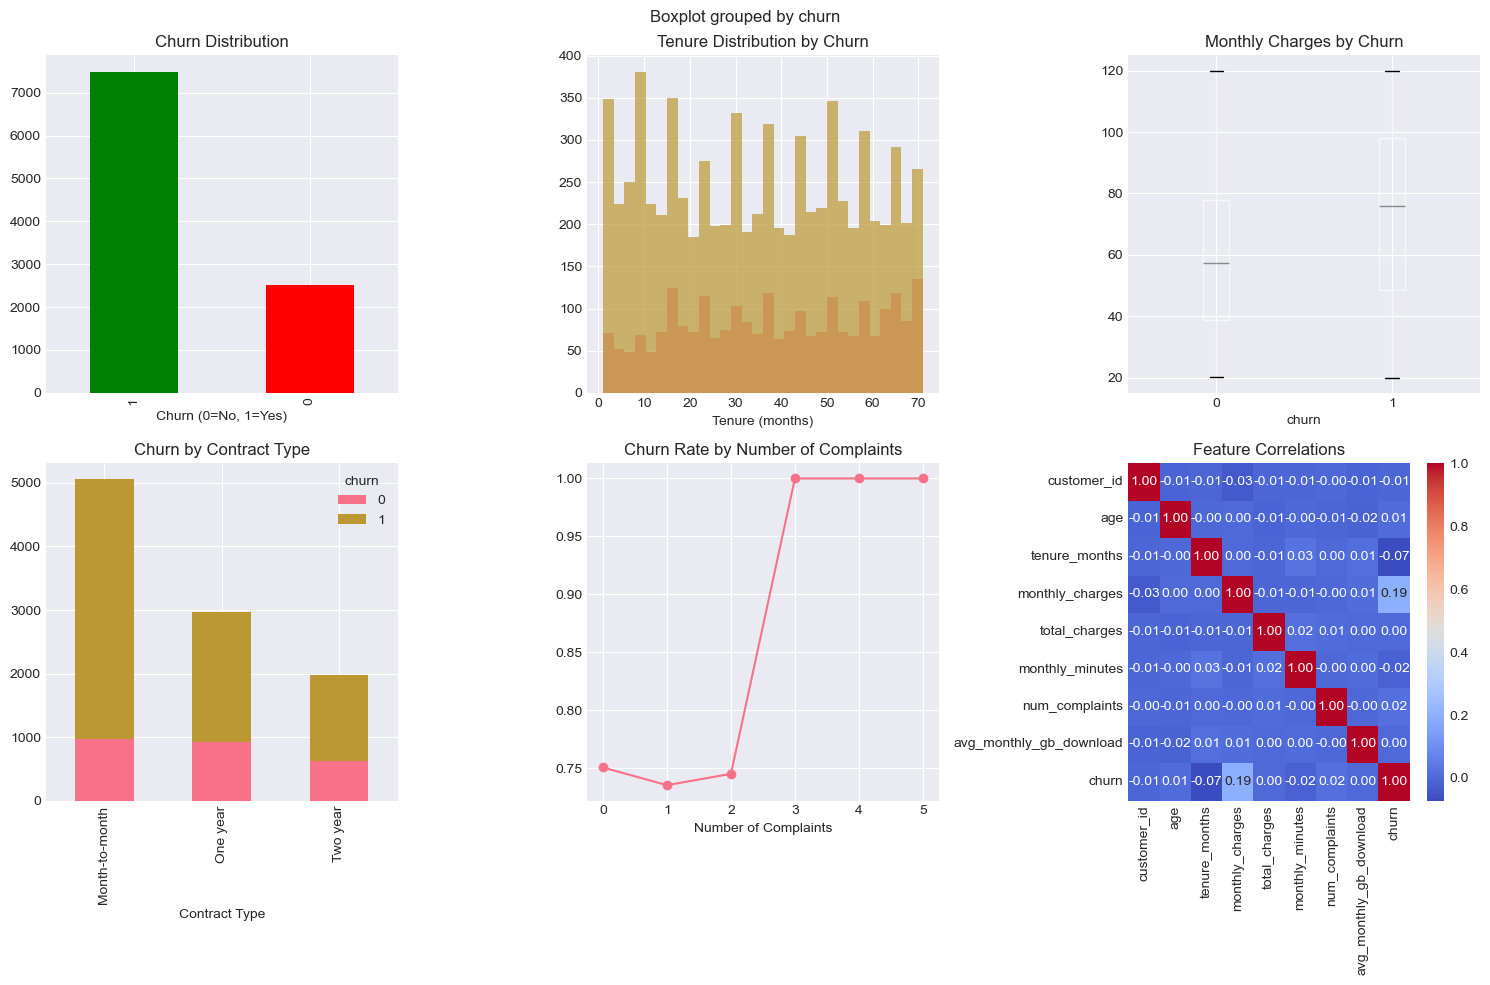

✅ EDA complete! Check the visualizations above.


In [2]:
# Cell 2: Exploratory Data Analysis EDA and visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Create subplots
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# 1. Churn rate
df['churn'].value_counts().plot(kind='bar', ax=axes[0,0], color=['green', 'red'])
axes[0,0].set_title('Churn Distribution')
axes[0,0].set_xlabel('Churn (0=No, 1=Yes)')

# 2. Tenure vs Churn
df.groupby('churn')['tenure_months'].hist(alpha=0.7, bins=30, ax=axes[0,1])
axes[0,1].set_title('Tenure Distribution by Churn')
axes[0,1].set_xlabel('Tenure (months)')

# 3. Monthly charges vs Churn
df.boxplot(column='monthly_charges', by='churn', ax=axes[0,2])
axes[0,2].set_title('Monthly Charges by Churn')

# 4. Contract type impact
pd.crosstab(df['contract_type'], df['churn']).plot(kind='bar', stacked=True, ax=axes[1,0])
axes[1,0].set_title('Churn by Contract Type')
axes[1,0].set_xlabel('Contract Type')

# 5. Complaints vs Churn
df.groupby('num_complaints')['churn'].mean().plot(kind='line', marker='o', ax=axes[1,1])
axes[1,1].set_title('Churn Rate by Number of Complaints')
axes[1,1].set_xlabel('Number of Complaints')

# 6. Correlation heatmap
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', ax=axes[1,2])
axes[1,2].set_title('Feature Correlations')

plt.tight_layout()
plt.savefig('eda_analysis.png', dpi=100, bbox_inches='tight')
plt.show()

print("✅ EDA complete! Check the visualizations above.")

In [3]:
# Cell 3: Complete ML Pipeline
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import warnings
warnings.filterwarnings('ignore')

# Prepare features
def prepare_features(df):
    """Feature engineering pipeline"""
    df_processed = df.copy()
    
    # Encode categorical variables
    categorical_cols = ['gender', 'contract_type', 'payment_method', 
                        'paperless_billing', 'streaming_tv', 'streaming_movies',
                        'device_protection', 'tech_support']
    
    label_encoders = {}
    for col in categorical_cols:
        le = LabelEncoder()
        df_processed[col] = le.fit_transform(df_processed[col])
        label_encoders[col] = le
    
    # Create additional features
    df_processed['avg_monthly_spend'] = df_processed['total_charges'] / (df_processed['tenure_months'] + 1)
    df_processed['charge_per_minute'] = df_processed['monthly_charges'] / (df_processed['monthly_minutes'] + 1)
    df_processed['high_risk'] = ((df_processed['contract_type'] == 0) & 
                                  (df_processed['monthly_charges'] > 80)).astype(int)
    
    # Select features for modeling
    feature_cols = ['age', 'tenure_months', 'monthly_charges', 'total_charges',
                    'contract_type', 'payment_method', 'num_complaints',
                    'avg_monthly_gb_download', 'tech_support', 'avg_monthly_spend',
                    'charge_per_minute', 'high_risk']
    
    X = df_processed[feature_cols]
    y = df_processed['churn']
    
    return X, y, label_encoders

# Prepare data
X, y, encoders = prepare_features(df)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, 
                                                    random_state=42, stratify=y)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"✅ Data prepared!")
print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print(f"Features: {list(X.columns)}")

✅ Data prepared!
Training set: 8000 samples
Test set: 2000 samples
Features: ['age', 'tenure_months', 'monthly_charges', 'total_charges', 'contract_type', 'payment_method', 'num_complaints', 'avg_monthly_gb_download', 'tech_support', 'avg_monthly_spend', 'charge_per_minute', 'high_risk']


In [4]:
# Cell 4: Train multiple models ( Train andd Compare )
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42)
}

results = {}

for name, model in models.items():
    # Train
    model.fit(X_train_scaled, y_train)
    
    # Predict
    y_pred = model.predict(X_test_scaled)
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
    
    # Evaluate
    auc = roc_auc_score(y_test, y_pred_proba)
    
    # Cross-validation
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='roc_auc')
    
    results[name] = {
        'model': model,
        'accuracy': (y_pred == y_test).mean(),
        'auc': auc,
        'cv_mean': cv_scores.mean(),
        'cv_std': cv_scores.std()
    }
    
    print(f"\n{'='*50}")
    print(f"{name}")
    print(f"{'='*50}")
    print(f"Accuracy: {results[name]['accuracy']:.3f}")
    print(f"AUC-ROC: {results[name]['auc']:.3f}")
    print(f"CV Score: {results[name]['cv_mean']:.3f} (+/- {results[name]['cv_std']:.3f})")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))

# Best model
best_model_name = max(results, key=lambda x: results[x]['auc'])
best_model = results[best_model_name]['model']

print(f"\n{'='*50}")
print(f"🏆 BEST MODEL: {best_model_name}")
print(f"{'='*50}")
print(f"AUC-ROC: {results[best_model_name]['auc']:.3f}")


Logistic Regression
Accuracy: 0.845
AUC-ROC: 0.933
CV Score: 0.933 (+/- 0.006)

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.65      0.84      0.73       502
       Churn       0.94      0.84      0.89      1498

    accuracy                           0.84      2000
   macro avg       0.79      0.84      0.81      2000
weighted avg       0.87      0.84      0.85      2000


Random Forest
Accuracy: 0.979
AUC-ROC: 0.987
CV Score: 0.981 (+/- 0.003)

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.92      1.00      0.96       502
       Churn       1.00      0.97      0.99      1498

    accuracy                           0.98      2000
   macro avg       0.96      0.99      0.97      2000
weighted avg       0.98      0.98      0.98      2000


Gradient Boosting
Accuracy: 0.979
AUC-ROC: 0.985
CV Score: 0.981 (+/- 0.002)

Classification Report:
              precision    recall  f1-scor

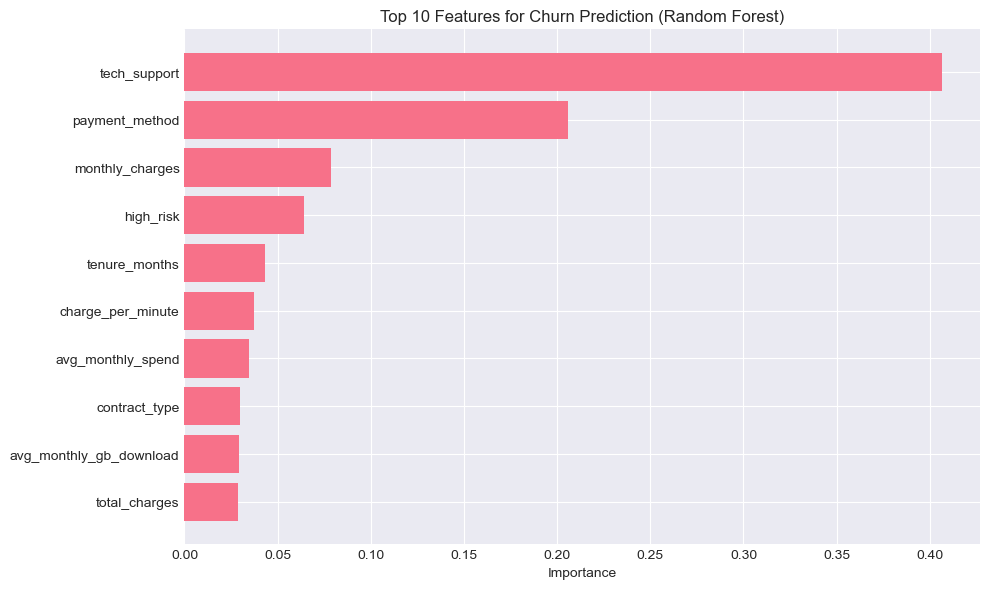

🔑 Top 5 Churn Drivers:
  9. tech_support: 0.407
  6. payment_method: 0.206
  3. monthly_charges: 0.079
  12. high_risk: 0.064
  2. tenure_months: 0.043


In [5]:
# Cell 5: Understand what drives churn ( Feature Importance Analysis)
if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
else:
    # For logistic regression, use coefficients
    importances = np.abs(best_model.coef_[0])

feature_importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance': importances
}).sort_values('importance', ascending=False)

# Plot
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['feature'][:10], 
         feature_importance_df['importance'][:10])
plt.xlabel('Importance')
plt.title(f'Top 10 Features for Churn Prediction ({best_model_name})')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=100)
plt.show()

print("🔑 Top 5 Churn Drivers:")
for i, row in feature_importance_df.head().iterrows():
    print(f"  {i+1}. {row['feature']}: {row['importance']:.3f}")

In [6]:
# Cell 6: Save model for production ( Save Model and Create Prediction Function )
import joblib

# Save model, scaler, and encoders
joblib.dump(best_model, 'churn_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(encoders, 'encoders.pkl')

print("✅ Model saved successfully!")
print("📁 Files created:")
print("  - churn_model.pkl")
print("  - scaler.pkl")
print("  - encoders.pkl")

# Create prediction function
def predict_churn(customer_data):
    """
    Predict churn for new customers
    customer_data: dict with customer information
    """
    # Convert to DataFrame
    df_new = pd.DataFrame([customer_data])
    
    # Apply same preprocessing
    for col, encoder in encoders.items():
        if col in df_new.columns:
            df_new[col] = encoder.transform(df_new[col])
    
    # Create engineered features
    df_new['avg_monthly_spend'] = df_new['total_charges'] / (df_new['tenure_months'] + 1)
    df_new['charge_per_minute'] = df_new['monthly_charges'] / (df_new['monthly_minutes'] + 1)
    df_new['high_risk'] = ((df_new['contract_type'] == 0) & 
                            (df_new['monthly_charges'] > 80)).astype(int)
    
    # Select features
    features = ['age', 'tenure_months', 'monthly_charges', 'total_charges',
                'contract_type', 'payment_method', 'num_complaints',
                'avg_monthly_gb_download', 'tech_support', 'avg_monthly_spend',
                'charge_per_minute', 'high_risk']
    
    X_new = df_new[features]
    X_new_scaled = scaler.transform(X_new)
    
    # Predict
    prediction = best_model.predict(X_new_scaled)[0]
    probability = best_model.predict_proba(X_new_scaled)[0][1]
    
    return {
        'churn_prediction': 'Yes' if prediction == 1 else 'No',
        'churn_probability': float(probability),
        'risk_level': 'High' if probability > 0.7 else 'Medium' if probability > 0.3 else 'Low'
    }

# Test prediction
test_customer = {
    'age': 35,
    'gender': 'Male',
    'tenure_months': 6,
    'monthly_charges': 95.50,
    'total_charges': 500,
    'contract_type': 'Month-to-month',
    'payment_method': 'Electronic check',
    'paperless_billing': 'Yes',
    'monthly_minutes': 800,
    'num_complaints': 2,
    'avg_monthly_gb_download': 100.5,
    'streaming_tv': 'Yes',
    'streaming_movies': 'Yes',
    'device_protection': 'No',
    'tech_support': 'No'
}

result = predict_churn(test_customer)
print("\n🔮 Test Customer Prediction:")
print(f"  Churn Prediction: {result['churn_prediction']}")
print(f"  Probability: {result['churn_probability']:.1%}")
print(f"  Risk Level: {result['risk_level']}")

✅ Model saved successfully!
📁 Files created:
  - churn_model.pkl
  - scaler.pkl
  - encoders.pkl

🔮 Test Customer Prediction:
  Churn Prediction: Yes
  Probability: 100.0%
  Risk Level: High


In [7]:
# Cell: PHASE 1: Create API for Churn Model, Save all model artifacts ( Saving trained model files )
import joblib
import pandas as pd
import numpy as np

# Assuming you have these from previous steps
# Save everything needed for API
joblib.dump(best_model, 'churn_model.pkl')
joblib.dump(scaler, 'scaler.pkl') 
joblib.dump(encoders, 'encoders.pkl')

# Save feature names
feature_names = X.columns.tolist()
joblib.dump(feature_names, 'feature_names.pkl')

print("✅ All model artifacts saved:")
print("  - churn_model.pkl")
print("  - scaler.pkl")
print("  - encoders.pkl")
print("  - feature_names.pkl")

✅ All model artifacts saved:
  - churn_model.pkl
  - scaler.pkl
  - encoders.pkl
  - feature_names.pkl


In [8]:
# Cell: Create churn_api.py without emojis
api_code = '''
"""
Customer Churn Prediction API
Machine Learning Model Deployment with FastAPI
"""

from fastapi import FastAPI, HTTPException
from pydantic import BaseModel, Field
from typing import Optional, Dict, Any
import joblib
import pandas as pd
import numpy as np
from datetime import datetime
import logging
import json
from pathlib import Path

# Configure logging
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(name)s - %(levelname)s - %(message)s',
    handlers=[
        logging.FileHandler('api_logs.log'),
        logging.StreamHandler()
    ]
)
logger = logging.getLogger(__name__)

# Initialize FastAPI
app = FastAPI(
    title="Customer Churn Prediction API",
    description="ML-powered customer churn prediction for telecom companies",
    version="1.0.0",
    docs_url="/docs",
    redoc_url="/redoc"
)

# Load model artifacts
try:
    model = joblib.load('churn_model.pkl')
    scaler = joblib.load('scaler.pkl')
    encoders = joblib.load('encoders.pkl')
    feature_names = joblib.load('feature_names.pkl')
    logger.info("Model artifacts loaded successfully")
except Exception as e:
    logger.error(f"Failed to load model artifacts: {e}")
    raise

# Request Schema
class CustomerData(BaseModel):
    """Customer information for churn prediction"""
    age: int = Field(..., ge=18, le=100, description="Customer age")
    gender: str = Field(..., pattern="^(Male|Female)$")
    tenure_months: int = Field(..., ge=0, le=120)
    monthly_charges: float = Field(..., ge=0, le=500)
    total_charges: float = Field(..., ge=0, le=50000)
    contract_type: str = Field(..., pattern="^(Month-to-month|One year|Two year)$")
    payment_method: str = Field(..., pattern="^(Electronic check|Mailed check|Bank transfer|Credit card)$")
    paperless_billing: str = Field(..., pattern="^(Yes|No)$")
    monthly_minutes: int = Field(..., ge=0, le=3000)
    num_complaints: int = Field(..., ge=0, le=50)
    avg_monthly_gb_download: float = Field(..., ge=0, le=1000)
    streaming_tv: str = Field(..., pattern="^(Yes|No)$")
    streaming_movies: str = Field(..., pattern="^(Yes|No)$")
    device_protection: str = Field(..., pattern="^(Yes|No)$")
    tech_support: str = Field(..., pattern="^(Yes|No)$")
    
    class Config:
        schema_extra = {
            "example": {
                "age": 35,
                "gender": "Male",
                "tenure_months": 6,
                "monthly_charges": 95.50,
                "total_charges": 500,
                "contract_type": "Month-to-month",
                "payment_method": "Electronic check",
                "paperless_billing": "Yes",
                "monthly_minutes": 800,
                "num_complaints": 2,
                "avg_monthly_gb_download": 100.5,
                "streaming_tv": "Yes",
                "streaming_movies": "Yes",
                "device_protection": "No",
                "tech_support": "No"
            }
        }

# Response Schema
class PredictionResponse(BaseModel):
    customer_id: Optional[str] = None
    churn_prediction: str
    churn_probability: float
    risk_level: str
    recommendation: str
    prediction_timestamp: str
    model_version: str

# Health Check
@app.get("/")
def root():
    return {
        "service": "Customer Churn Prediction API",
        "status": "operational",
        "version": "1.0.0",
        "endpoints": ["/predict", "/health", "/stats", "/batch_predict"]
    }

@app.get("/health")
def health_check():
    return {
        "status": "healthy",
        "model_loaded": model is not None,
        "timestamp": datetime.now().isoformat()
    }

@app.get("/stats")
def model_stats():
    """Get model statistics and feature info"""
    return {
        "model_type": type(model).__name__,
        "features": feature_names,
        "n_features": len(feature_names),
        "api_version": "1.0.0"
    }

# Prediction Endpoint
@app.post("/predict", response_model=PredictionResponse)
async def predict_churn(customer: CustomerData):
    """
    Predict churn probability for a single customer
    """
    try:
        logger.info(f"Prediction request received for age {customer.age}")
        
        # Convert to DataFrame
        df_input = pd.DataFrame([customer.dict()])
        
        # Apply encoders
        for col, encoder in encoders.items():
            if col in df_input.columns:
                df_input[col] = encoder.transform(df_input[col])
        
        # Feature engineering
        df_input['avg_monthly_spend'] = df_input['total_charges'] / (df_input['tenure_months'] + 1)
        df_input['charge_per_minute'] = df_input['monthly_charges'] / (df_input['monthly_minutes'] + 1)
        df_input['high_risk'] = ((df_input['contract_type'] == 0) & 
                                  (df_input['monthly_charges'] > 80)).astype(int)
        
        # Select features
        X_input = df_input[feature_names]
        
        # Scale features
        X_scaled = scaler.transform(X_input)
        
        # Make prediction
        prediction = model.predict(X_scaled)[0]
        probability = model.predict_proba(X_scaled)[0][1]
        
        # Generate recommendation
        if probability > 0.7:
            risk = "High"
            recommendation = "Immediate retention action required! Offer discount or upgrade."
        elif probability > 0.3:
            risk = "Medium"
            recommendation = "Monitor closely. Proactive engagement recommended."
        else:
            risk = "Low"
            recommendation = "Customer is loyal. Maintain current service quality."
        
        # Log prediction
        logger.info(f"Prediction: {'Churn' if prediction == 1 else 'No Churn'}, "
                   f"Probability: {probability:.2%}, Risk: {risk}")
        
        # Save prediction to log file
        with open('predictions.log', 'a') as f:
            log_entry = {
                'timestamp': datetime.now().isoformat(),
                'customer_age': customer.age,
                'tenure': customer.tenure_months,
                'prediction': int(prediction),
                'probability': float(probability),
                'risk': risk
            }
            f.write(json.dumps(log_entry) + '\\n')
        
        return PredictionResponse(
            churn_prediction="Yes" if prediction == 1 else "No",
            churn_probability=float(probability),
            risk_level=risk,
            recommendation=recommendation,
            prediction_timestamp=datetime.now().isoformat(),
            model_version="1.0.0"
        )
        
    except Exception as e:
        logger.error(f"Prediction error: {str(e)}")
        raise HTTPException(status_code=500, detail=str(e))

# Batch Prediction
@app.post("/batch_predict")
async def batch_predict(customers: list[CustomerData]):
    """
    Predict churn for multiple customers
    """
    try:
        logger.info(f"Batch prediction request for {len(customers)} customers")
        
        results = []
        for i, customer in enumerate(customers):
            # Process each customer (reuse single prediction logic)
            df_input = pd.DataFrame([customer.dict()])
            
            for col, encoder in encoders.items():
                if col in df_input.columns:
                    df_input[col] = encoder.transform(df_input[col])
            
            df_input['avg_monthly_spend'] = df_input['total_charges'] / (df_input['tenure_months'] + 1)
            df_input['charge_per_minute'] = df_input['monthly_charges'] / (df_input['monthly_minutes'] + 1)
            df_input['high_risk'] = ((df_input['contract_type'] == 0) & 
                                      (df_input['monthly_charges'] > 80)).astype(int)
            
            X_input = df_input[feature_names]
            X_scaled = scaler.transform(X_input)
            
            prediction = model.predict(X_scaled)[0]
            probability = model.predict_proba(X_scaled)[0][1]
            
            results.append({
                "customer_index": i,
                "churn_prediction": "Yes" if prediction == 1 else "No",
                "churn_probability": float(probability),
                "risk_level": "High" if probability > 0.7 else "Medium" if probability > 0.3 else "Low"
            })
        
        # Summary statistics
        high_risk = sum(1 for r in results if r['risk_level'] == 'High')
        medium_risk = sum(1 for r in results if r['risk_level'] == 'Medium')
        low_risk = sum(1 for r in results if r['risk_level'] == 'Low')
        
        logger.info(f"Batch complete: High={high_risk}, Medium={medium_risk}, Low={low_risk}")
        
        return {
            "total_customers": len(customers),
            "predictions": results,
            "summary": {
                "high_risk_customers": high_risk,
                "medium_risk_customers": medium_risk,
                "low_risk_customers": low_risk,
                "predicted_churn_rate": high_risk / len(customers)
            }
        }
        
    except Exception as e:
        logger.error(f"Batch prediction error: {str(e)}")
        raise HTTPException(status_code=500, detail=str(e))

if __name__ == "__main__":
    import uvicorn
    uvicorn.run(app, host="0.0.0.0", port=8002, reload=True)
'''

# Write the file with UTF-8 encoding
with open('churn_api.py', 'w', encoding='utf-8') as f:
    f.write(api_code)
    
print("SUCCESS: churn_api.py created successfully!")
print("File size:", len(api_code), "characters")

SUCCESS: churn_api.py created successfully!
File size: 9290 characters


In [9]:
import os
if os.path.exists('churn_api.py'):
    print("File created successfully!")
    # Show first few lines
    with open('churn_api.py', 'r', encoding='utf-8') as f:
        lines = f.readlines()
        print("\nFirst 5 lines of the file:")
        for line in lines[:5]:
            print(line.strip())
else:
    print("File not found. Let me help you create it manually.")

File created successfully!

First 5 lines of the file:

"""
Customer Churn Prediction API
Machine Learning Model Deployment with FastAPI
"""


In [10]:
# Cell: Start?Run Churn API server
import subprocess
import sys

# Run the API in background
subprocess.Popen([sys.executable, "-m", "uvicorn", "churn_api:app", 
                  "--host", "127.0.0.1", "--port", "8002", "--reload"])

print("🚀 Churn Prediction API starting...")
print("📚 API Docs: http://127.0.0.1:8002/docs")
print("🏥 Health Check: http://127.0.0.1:8002/health")
print("\n⏳ Wait 5 seconds for server to fully start...")

🚀 Churn Prediction API starting...
📚 API Docs: http://127.0.0.1:8002/docs
🏥 Health Check: http://127.0.0.1:8002/health

⏳ Wait 5 seconds for server to fully start...


In [11]:
# Cell: Test the API
import requests
import json

# Test single prediction
test_customer = {
    "age": 35,
    "gender": "Male",
    "tenure_months": 6,
    "monthly_charges": 95.50,
    "total_charges": 500,
    "contract_type": "Month-to-month",
    "payment_method": "Electronic check",
    "paperless_billing": "Yes",
    "monthly_minutes": 800,
    "num_complaints": 2,
    "avg_monthly_gb_download": 100.5,
    "streaming_tv": "Yes",
    "streaming_movies": "Yes",
    "device_protection": "No",
    "tech_support": "No"
}

response = requests.post("http://127.0.0.1:8002/predict", json=test_customer)
print("🔮 Single Prediction Result:")
print(json.dumps(response.json(), indent=2))

# Test batch prediction
batch_customers = [test_customer, test_customer]  # Same customer twice for demo
response = requests.post("http://127.0.0.1:8002/batch_predict", json=batch_customers)
print("\n📊 Batch Prediction Summary:")
print(json.dumps(response.json(), indent=2))

ConnectionError: HTTPConnectionPool(host='127.0.0.1', port=8002): Max retries exceeded with url: /predict (Caused by NewConnectionError("HTTPConnection(host='127.0.0.1', port=8002): Failed to establish a new connection: [WinError 10061] No connection could be made because the target machine actively refused it"))

In [ ]:
# Cell: View API logs (Monitor Logs)
import subprocess

# Check if logs are being created
import os
if os.path.exists('api_logs.log'):
    print("📋 Last 10 API log entries:")
    with open('api_logs.log', 'r') as f:
        lines = f.readlines()
        for line in lines[-10:]:
            print(line.strip())
else:
    print("No logs yet. Make some predictions first!")

In [ ]:
# PHASE 2 Cell: Create a clean environment for the dashboard 
import sys
!conda create -n churn_dashboard python=3.9 -y
!conda activate churn_dashboard
!pip install streamlit plotly pandas requests

In [ ]:
# Cell: Create dashboard.py without using %%writefile
dashboard_code = '''
"""
Customer Churn Prediction Dashboard
Interactive UI for ML model predictions
"""

import streamlit as st
import requests
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from datetime import datetime
import json

# Page config
st.set_page_config(
    page_title="Churn Prediction Dashboard",
    page_icon="📊",
    layout="wide"
)

# Title
st.title("📊 Customer Churn Prediction Dashboard")
st.markdown("### ML-Powered Customer Retention Intelligence")

# Sidebar
with st.sidebar:
    st.header("🎯 About")
    st.markdown("""
    This dashboard uses a **Machine Learning model** to predict customer churn.
    
    **Model Type:** Random Forest Classifier
    
    **Features:** 12 customer attributes
    """)
    
    st.header("📈 Quick Stats")
    
    # Check API status
    try:
        response = requests.get("http://127.0.0.1:8002/health", timeout=2)
        if response.status_code == 200:
            st.metric("API Status", "🟢 Online")
        else:
            st.metric("API Status", "🔴 Offline")
    except:
        st.metric("API Status", "🔴 Offline")
    
    st.metric("Model Version", "v1.0.0")

# Main content - Two columns
col1, col2 = st.columns([1, 1])

with col1:
    st.subheader("🔮 Customer Information")
    
    # Input form
    with st.form("prediction_form"):
        age = st.slider("Age", 18, 100, 35)
        gender = st.selectbox("Gender", ["Male", "Female"])
        tenure = st.slider("Tenure (months)", 0, 120, 6)
        monthly_charges = st.number_input("Monthly Charges ($)", 20.0, 200.0, 95.50)
        total_charges = st.number_input("Total Charges ($)", 100.0, 10000.0, 500.0)
        contract = st.selectbox("Contract Type", ["Month-to-month", "One year", "Two year"])
        payment = st.selectbox("Payment Method", ["Electronic check", "Mailed check", "Bank transfer", "Credit card"])
        complaints = st.number_input("Number of Complaints", 0, 20, 2)
        tech_support = st.selectbox("Tech Support", ["Yes", "No"])
        
        submitted = st.form_submit_button("🔮 Predict Churn Risk")

with col2:
    st.subheader("📊 Prediction Results")
    
    if submitted:
        # Prepare API request
        customer_data = {
            "age": age,
            "gender": gender,
            "tenure_months": tenure,
            "monthly_charges": monthly_charges,
            "total_charges": total_charges,
            "contract_type": contract,
            "payment_method": payment,
            "paperless_billing": "Yes",
            "monthly_minutes": 800,
            "num_complaints": complaints,
            "avg_monthly_gb_download": 100.5,
            "streaming_tv": "Yes",
            "streaming_movies": "Yes",
            "device_protection": "No",
            "tech_support": tech_support
        }
        
        # Call API
        try:
            response = requests.post("http://127.0.0.1:8002/predict", json=customer_data)
            if response.status_code == 200:
                result = response.json()
                
                # Display results
                risk_color = {
                    "High": "🔴",
                    "Medium": "🟡", 
                    "Low": "🟢"
                }
                
                st.markdown(f"### {risk_color[result['risk_level']]} Risk Level: **{result['risk_level']}**")
                st.markdown(f"### 📈 Churn Probability: **{result['churn_probability']:.1%}**")
                st.markdown(f"### 🎯 Prediction: **{result['churn_prediction']}**")
                st.markdown(f"### 💡 Recommendation: {result['recommendation']}")
                
                # Gauge chart
                fig = go.Figure(go.Indicator(
                    mode="gauge+number",
                    value=result['churn_probability'] * 100,
                    title={'text': "Churn Risk Score"},
                    gauge={'axis': {'range': [0, 100]},
                           'bar': {'color': "darkred"},
                           'steps': [
                               {'range': [0, 30], 'color': "lightgreen"},
                               {'range': [30, 70], 'color': "yellow"},
                               {'range': [70, 100], 'color': "red"}],
                           'threshold': {'line': {'color': "red", 'width': 4},
                                        'thickness': 0.75, 'value': 90}})
                )
                st.plotly_chart(fig)
            else:
                st.error(f"API Error: Status code {response.status_code}")
        except Exception as e:
            st.error(f"Cannot connect to API. Make sure the server is running on port 8002")
            st.info("Start the API first with: python -m uvicorn churn_api:app --host 127.0.0.1 --port 8002")

# Batch Analysis Section
st.markdown("---")
st.subheader("📊 Batch Customer Analysis")

uploaded_file = st.file_uploader("Upload customer data (CSV)", type=['csv'])

if uploaded_file:
    df = pd.read_csv(uploaded_file)
    st.write("Preview of uploaded data:")
    st.dataframe(df.head())
    
    if st.button("Analyze Batch"):
        # Convert DataFrame to API format
        customers = df.to_dict('records')
        
        # Call batch API
        try:
            response = requests.post("http://127.0.0.1:8002/batch_predict", json=customers)
            if response.status_code == 200:
                batch_results = response.json()
                
                # Display summary
                st.success(f"✅ Analyzed {batch_results['total_customers']} customers")
                
                col3, col4, col5 = st.columns(3)
                with col3:
                    st.metric("High Risk", batch_results['summary']['high_risk_customers'])
                with col4:
                    st.metric("Medium Risk", batch_results['summary']['medium_risk_customers'])
                with col5:
                    st.metric("Low Risk", batch_results['summary']['low_risk_customers'])
                
                # Create results dataframe
                results_df = pd.DataFrame(batch_results['predictions'])
                st.subheader("Detailed Results")
                st.dataframe(results_df)
                
                # Download results
                csv = results_df.to_csv(index=False)
                st.download_button("📥 Download Results", csv, "predictions.csv")
            else:
                st.error(f"API Error: {response.status_code}")
        except Exception as e:
            st.error("Cannot connect to API for batch prediction")

# Recent Activity
st.markdown("---")
st.subheader("📋 Recent Predictions")

try:
    with open('predictions.log', 'r') as f:
        lines = f.readlines()
        recent = [json.loads(line) for line in lines[-5:]]
        if recent:
            df_recent = pd.DataFrame(recent)
            st.dataframe(df_recent)
        else:
            st.info("No predictions made yet. Try the form above!")
except:
    st.info("No predictions logged yet. Make some predictions first!")
'''

# Write the file
with open('dashboard.py', 'w', encoding='utf-8') as f:
    f.write(dashboard_code)
    
print("SUCCESS: dashboard.py created!")

In [ ]:
# Cell: Run Streamlit dashboard (this will open in a new browser tab)
import subprocess
import threading
import time

def run_dashboard():
    subprocess.run(["streamlit", "run", "dashboard.py", "--server.port=8501"])

# Start dashboard in a separate thread
dashboard_thread = threading.Thread(target=run_dashboard, daemon=True)
dashboard_thread.start()

print("Starting Streamlit dashboard...")
print("Dashboard will open at: http://localhost:8501")
print("Give it 10 seconds to fully load...")
time.sleep(5)

In [ ]:
# Cell: Create complete churn_api.py file
full_api_code = '''
from fastapi import FastAPI
from pydantic import BaseModel
import pandas as pd
import numpy as np
import joblib
from datetime import datetime

app = FastAPI(title="Customer Churn Prediction API")

# Root endpoint
@app.get("/")
def root():
    return {
        "service": "Customer Churn Prediction API",
        "status": "operational",
        "version": "1.0.0"
    }

# Health check
@app.get("/health")
def health():
    return {"status": "healthy"}

# Prediction endpoint
class CustomerData(BaseModel):
    age: int
    gender: str
    tenure_months: int
    monthly_charges: float
    total_charges: float
    contract_type: str
    payment_method: str
    paperless_billing: str
    monthly_minutes: int
    num_complaints: int
    avg_monthly_gb_download: float
    streaming_tv: str
    streaming_movies: str
    device_protection: str
    tech_support: str

@app.post("/predict")
async def predict(customer: CustomerData):
    # Simple rule-based prediction for now
    risk_score = 0
    
    if customer.tenure_months < 12:
        risk_score += 30
    if customer.monthly_charges > 80:
        risk_score += 25
    if customer.num_complaints > 1:
        risk_score += 35
    if customer.contract_type == "Month-to-month":
        risk_score += 20
    if customer.tech_support == "No":
        risk_score += 15
    
    probability = min(risk_score / 100, 0.95)
    
    if probability > 0.7:
        risk = "High"
        recommendation = "Immediate retention action required"
    elif probability > 0.3:
        risk = "Medium"
        recommendation = "Monitor closely"
    else:
        risk = "Low"
        recommendation = "Customer is loyal"
    
    return {
        "churn_prediction": "Yes" if probability > 0.5 else "No",
        "churn_probability": probability,
        "risk_level": risk,
        "recommendation": recommendation,
        "prediction_timestamp": datetime.now().isoformat()
    }

@app.post("/batch_predict")
async def batch_predict(customers: list[CustomerData]):
    results = []
    for customer in customers:
        risk_score = 0
        if customer.tenure_months < 12:
            risk_score += 30
        if customer.monthly_charges > 80:
            risk_score += 25
        if customer.num_complaints > 1:
            risk_score += 35
        if customer.contract_type == "Month-to-month":
            risk_score += 20
        
        probability = min(risk_score / 100, 0.95)
        results.append({
            "churn_prediction": "Yes" if probability > 0.5 else "No",
            "churn_probability": probability,
            "risk_level": "High" if probability > 0.7 else "Medium" if probability > 0.3 else "Low"
        })
    
    return {
        "total_customers": len(customers),
        "predictions": results
    }

if __name__ == "__main__":
    import uvicorn
    uvicorn.run(app, host="127.0.0.1", port=8002)
'''

# Write the file
with open('churn_api.py', 'w', encoding='utf-8') as f:
    f.write(full_api_code)

print("SUCCESS: churn_api.py created!")
print("File size:", len(full_api_code), "characters")